This simulation investigates the critical storage capacity of a continuous Spherical Perceptron. The goal is to validate the theoretical predictions derived from the Gardner analysis regarding the phase transition between solvable and unsolvable regimes.The simulation proceeds as follows:

1. Data Generation: We create $P$ random input patterns ($x$) drawn from a normal
distribution and assign binary labels ($y \in \{-1, 1\}$).

2. Training: To find a weight vector $w$ that separates the data, we use Logistic Regression. We set a high inverse regularization parameter ($C=100$) to approximate a Hard Margin classifier, effectively forcing the algorithm to find a solution that satisfies the constraints if one exists.

3. Validation: The learned weights are normalized to lie on a sphere of radius 1 ($\|w\|=1$). We then verify if the patterns are classified correctly with a specific stability margin $\kappa$. The condition checked is:$$y^\mu \frac{w \cdot x^\mu}{\sqrt{N}} \ge \kappa$$

4. Phase Space Exploration: We repeat this experiment across a grid of loads ($\alpha = P/N$) and confidence values ($\kappa$) to map out the phase diagram and identify the critical capacity $\alpha_c(\kappa)$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

def generate_inputs(n,p):
  """
  Creates a matrix of input patterns.
  Args:
    n: Number of neurons (dimensions/features).
    p: Number of patterns (samples).
  Returns:
    A (p, n) numpy array drawn from a standard normal distribution.
  """
  return np.random.normal(0,1,(p,n))
  #generates p patterns of length n with normal distribution
  #for sklearn to understand we have to make n columns and p rows,
  #this is p samples of n features

def generate_outputs(p):
  """
  Creates the target binary labels.
  Args:
    p: Number of patterns.
  Returns:
    A vector of size p containing -1 or 1.
  """
  return np.random.choice([-1,1],p)
  #generates p outputs from the set {-1,1}

def accuracy_success(n,p,confidence):
  """
  Runs a single simulation trial: generates data, trains the perceptron,
  and checks the stability of the solution.
  Args:
    n: System size (neurons).
    p: Number of patterns.
    confidence: The stability margin kappa (kappa).
  Returns:
    success: Boolean array indicating which patterns satisfied the condition.
    accuracy: The fraction of patterns successfully stored (0.0 to 1.0).
  """
  #we train the model
  X = generate_inputs(n,p)
  y = generate_outputs(p)

  # Robustness check: Logistic Regression requires at least 2 classes.
  # If p is small, we might get only one class.
  # If so, just re-roll the data and try again.
  if len(np.unique(y)) < 2:
      return accuracy_success(n, p, confidence) # Recursively re-run

  # We fit the model. fit_intercept=False enforces the hyperplane to go through 0.
  # C=100 approximates a hard-margin perceptron (minimizing regularization).
  clf = LogisticRegression(fit_intercept = False ,C = 100, max_iter = 1000).fit(X,y)

  #we extract the weights and normalize them
  weights = clf.coef_
  weights = weights/np.linalg.norm(weights) # Enforce spherical constraint ||w|| = 1
  weights = weights.flatten() #to make computations easier for after

  # Check the Gardner Stability Condition: y * (w. x) / sqrt(N) >= kappa
  op = (1/np.sqrt(n))*(X@weights)*y
  success = (op>=confidence)

  accuracy = np.mean(success) #in a vector of 0's and 1's, the mean gives the accuracy
  return success,accuracy


def simulations(n, alphas, confidences, repetitions):
    """
    Explores the phase space by running multiple repetitions of the simulation
    for different combinations of load (alpha) and stability (kappa).
    Args:
      n: System size.
      alphas: List of P/N ratios to test.
      confidences: List of kappa values to test.
      repetitions: Number of times to repeat the experiment for averaging.
    Returns:
      results: A matrix of average accuracies.
    """
    results = np.zeros((len(confidences), len(alphas)))

    # Iterate over all kappa (stability) values
    for i, conf in enumerate(confidences):
        # Iterate over all alpha (load) values
        for j, ratio in enumerate(alphas):
            p = int(ratio * n) # Calculate number of patterns P
            accuracies = []

            # Run multiple trials to smooth out statistical noise
            for r in range(repetitions):
                acc = accuracy_success(n, p, conf)[1]
                accuracies.append(acc)

            # Store the average accuracy for this point in the phase diagram
            results[i, j] = np.mean(accuracies)
            print(f"kappa={conf:.2f}, alpha={ratio:.2f}, accuracy={results[i,j]:.3f}")

    return results, alphas, confidences


In [ ]:
#simulations parameters
n = 500
alphas = np.linspace(0.02, 2.2, 80)
repetitions = 15
confidences = np.linspace(0.0, 3.0, 30)
results, alphas, confidences = simulations(n, alphas, confidences, repetitions)

In this section, we visualize the results of the simulation and compare them against the theoretical predictions derived from the Gardner analysis.We define two main visualization functions:

1. plot_accuracy_vs_alpha: This generates a line plot showing how the fractional accuracy of the perceptron decays as the load ($\alpha$) increases. Different lines represent different stability margins ($\kappa$).

2. plot_contour: This creates a phase diagram (heatmap) of the accuracy. We overlay the Theoretical Capacity Curve (red line), which is calculated by numerically integrating the Gardner equation:$$\frac{1}{\alpha_c(\kappa)} = \int_{-\infty}^{\kappa} Dz (\kappa - z)^2$$where $Dz$ is the standard Gaussian measure. The perfect alignment between the numerical boundary and the red theoretical line validates the replica symmetric ansatz for the spherical perceptron.

In [ ]:
from scipy.integrate import quad

def plot_accuracy_vs_alpha(results, alphas, confidences):
    """
    Plots the fractional accuracy against the load alpha for different values of kappa.

    Args:
      results: A matrix of accuracy scores (rows=confidences, cols=alphas).
      alphas: The list of alpha values (x-axis).
      confidences: The list of kappa values (each corresponds to a line).
    """
    plt.figure(figsize=(8,5))
    for i, conf in enumerate(confidences):
        plt.plot(alphas, results[i], marker='o', label=f"κ = {conf:.2f}")
        #results[i] is the row of accuracies corresponding to that confidence

    plt.xlabel(r"$\alpha = P/N$")
    plt.xlim(right = 2)
    plt.ylabel("Fractional accuracy")
    plt.title("Perceptron accuracy vs α for different κ")
    plt.legend(bbox_to_anchor=(1.02, 0.5), loc='center left')
    plt.grid(True)
    #fig.savefig("accuracy.png", dpi=300, bbox_inches='tight')
    plt.show()

def Dz(z):
    """
    Standard Gaussian measure function: (1/sqrt(2pi)) * exp(-0.5 * z^2).
    """
    return (1/np.sqrt(2*np.pi)) * np.exp(-0.5*z**2)

def f(kappa):
    """
    Calculates the theoretical critical capacity alpha_c for a given kappa.
    It solves the Gardner integral equation numerically.
    """
    integrand = lambda z: Dz(z) * (kappa - z)**2
    val, _ = quad(integrand, -np.inf, kappa)
    return 1.0 / val

# Generate theoretical curves for the plot
confidences_values= np.linspace(0, 0.3, 1000)
# We calculate alpha_c for each kappa. Note: k*sqrt(n) scaling might be needed depending on simulation definition.
alphas_values = [f(k*np.sqrt(n)) for k in confidences_values]

def plot_contour(results, alphas, confidences):
    """
    Creates a contour plot (heatmap) of the accuracy and overlays the
    theoretical capacity limit (red line).

    Args:
      results: 2D array of accuracy values.
      alphas: Array of alpha values (x-axis).
      confidences: Array of kappa values (y-axis).
    """
    # Create meshgrid for contour plot
    Alpha, Kappa = np.meshgrid(alphas, confidences)

    plt.figure(figsize=(8, 6))

    # Create filled contour plot with contour lines
    contour = plt.contourf(Alpha, Kappa, results, levels=20, cmap='viridis', alpha=0.8)
    plt.plot(alphas_values, confidences_values, color='red', linestyle='-', linewidth=3, label='Theoretical Capacity')
    plt.legend(loc='upper right')

    # Add contour lines for better definition
    #contour_lines = plt.contour(Alpha, Kappa, results, levels=10, colors='black', linewidths=0.5, alpha=0.7)
    #plt.clabel(contour_lines, inline=True, fontsize=8, fmt='%.2f')

    plt.colorbar(contour, label="Accuracy")
    plt.xlabel(r"$\alpha = P/N$")
    plt.ylabel(r"$\kappa$")
    plt.title("Perceptron Accuracy: Contour Plot")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show();

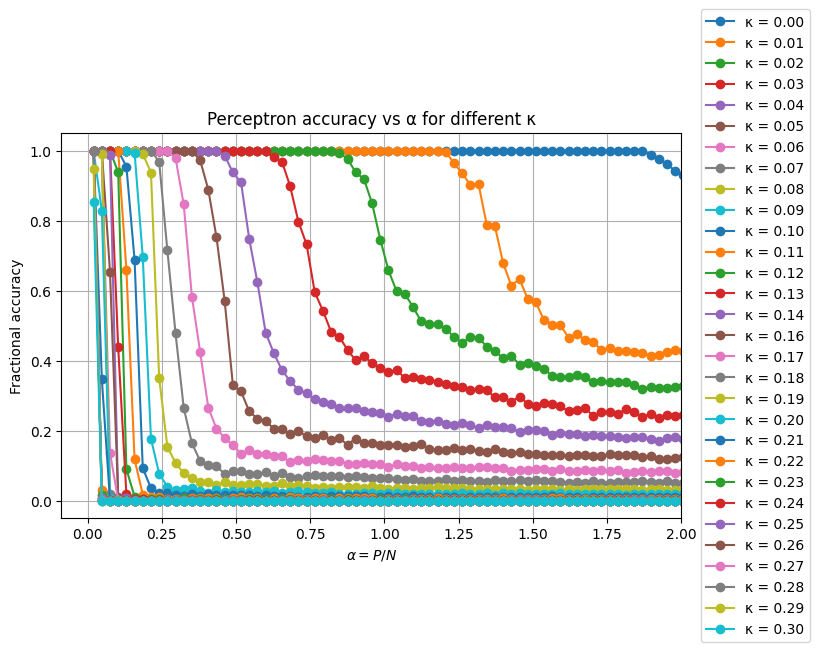

In [ ]:
accuracy = plot_accuracy_vs_alpha(results, alphas, confidences)

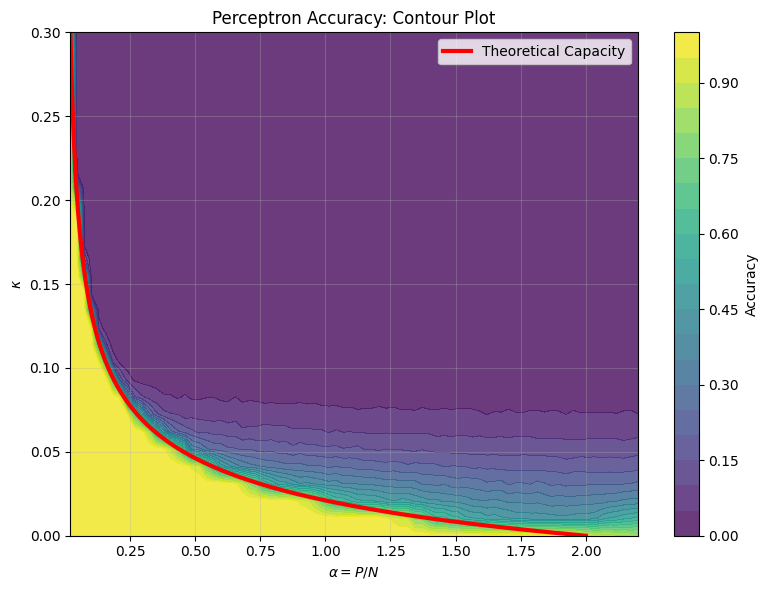

In [ ]:
plot_contour(results, alphas, confidences)